# Chapter 1 - Build Your First Neural Network

A **neural network** is a function approximator. It takes a vector of numbers as input and transforms it through a stack of **layers**, each of which applies a weighted sum followed by a non-linear **activation function**.

In this chapter we build the "Hello World" of deep learning: a feed-forward network that reads 28x28 pixel images of handwritten digits (the MNIST dataset) and classifies them into the digits 0-9.

## Why MNIST?
MNIST is a classic dataset: 60,000 training images + 10,000 test images of digits, collected in the 1980s. It is tiny (28x28 grayscale) so it trains in seconds on a laptop CPU, which makes it perfect for learning the mechanics of `tf.keras`.

## The building blocks
- `Input`: the shape of input samples.
- `Flatten`: 28x28 = 784 pixels into one long vector.
- `Dense`: a "fully connected" layer of neurons (learned matrix multiply + bias).
- `activation="relu"`: keeps values positive (helps gradients flow).
- `Dropout`: randomly turns off neurons during training to fight overfitting.
- `softmax`: turns raw scores into class probabilities summing to 1.

**Teacher line: a network "learns" by adjusting the numeric weights inside each `Dense` layer to reduce a loss function, using gradients computed via backpropagation.**

## Step 1 - imports
We will use **TensorFlow + Keras 3**, the modern dual API. The dataset ships with Keras, no download is needed from our side at runtime the first time (Keras fetches it once).

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.datasets import mnist
from keras import layers, models

print("TensorFlow/Keras", keras.__version__)

TensorFlow/Keras 3.15.1


## Step 2 - load & normalize
Pixel values range 0-255; networks train far more reliably on small, zero-centered inputs, so we divide by 255 to get values in [0, 1].

In [2]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

print("train shape:", train_images.shape, "label range:", train_labels.min(), "-", train_labels.max())

train shape: (60000, 28, 28) label range: 0 - 9


## Step 3 - our first model
Functional is chosen over Sequential only to show both APIs later; here we keep it simple.

In [3]:
model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax"),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Wait--let me be honest about something important: **the flatten layer destroys the 2D spatial structure** of the image. That is expected here: for `Dense` layers every pixel connects to every neuron. Later (convnets chapter) we exploit spatial structure on purpose.

## Step 4 - compile & train
- `loss="sparse_categorical_crossentropy"` because labels are integers (not one-hot).
- `"adam"` is an adaptive step-size optimizer.
- `accuracy` reports what fraction of predictions agree with the true label.

In [4]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [5]:
history = model.fit(
    train_images, train_labels,
    validation_data=(test_images, test_labels),
    epochs=10, batch_size=128, verbose=1,
)

Epoch 1/10


  1/469 ━━━━━━━━━━━━━━━━━━━━ 4:42 604ms/step - accuracy: 0.0703 - loss: 2.3622

 29/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5935 - loss: 1.4338    

 58/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7119 - loss: 1.0324

 88/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7616 - loss: 0.8441

...

378/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9825 - loss: 0.0564

407/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9824 - loss: 0.0566

436/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9824 - loss: 0.0568

465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9824 - loss: 0.0567

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9823 - loss: 0.0568 - val_accuracy: 0.9790 - val_loss: 0.0672


## Step 5 - inspect the learning curve
The loss should drop and accuracy climb on both training & validation. If `val_loss` grows while train keeps falling, that's overfitting (chapter 5).

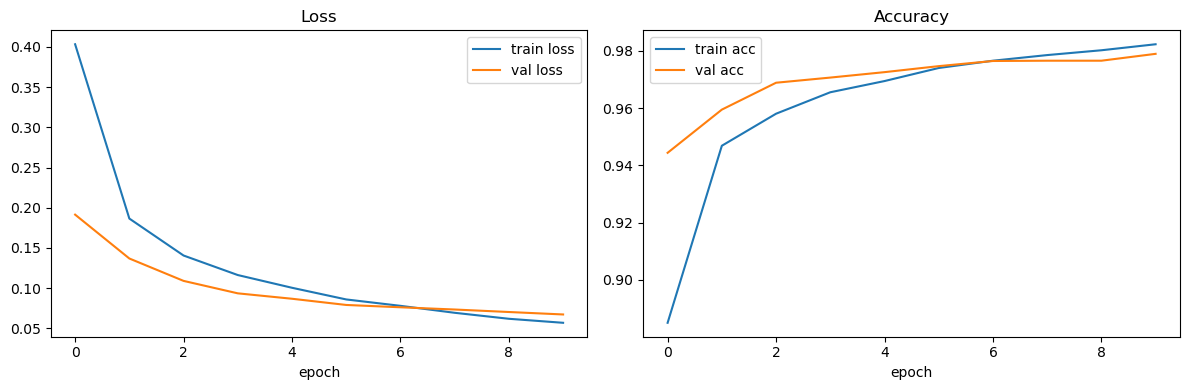

In [6]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history["loss"], label="train loss")
    ax[0].plot(history.history["val_loss"], label="val loss")
    ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(history.history["accuracy"], label="train acc")
    ax[1].plot(history.history["val_accuracy"], label="val acc")
    ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history)

In [7]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9790


## Step 6 - predictions & sanity check
A `softmax` output means each validation image gets a probability distribution over digits. Argmax picks the most confident class.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


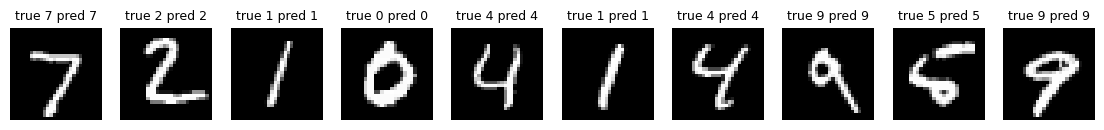

In [8]:
preds = model.predict(test_images[:10])
pred_classes = preds.argmax(axis=-1)

fig, axes = plt.subplots(1, 10, figsize=(14, 4))
for i, ax in enumerate(axes):
    ax.imshow(test_images[i], cmap="gray")
    ax.set_title(f"true {test_labels[i]} pred {pred_classes[i]}", fontsize=9)
    ax.axis("off")
plt.show()

## Recap
- A network = stacked layers of weighted matrix operations followed by nonlinear activation.
- `Flatten` → 784 values, `Dense(128, relu)` mixes them, `Softmax` converts to probabilities.
- Train by minimizing cross-entropy with the Adam optimizer.
- ~98% test accuracy on MNIST is a bare minimum from scratch; the convnets chapter pushes above 99%.